# Bayesian Posterior as Prior–Likelihood Fusion

Bayesian inference combines prior belief and data evidence through:
$$
p(\theta\mid y)\propto p(y\mid\theta)\,p(\theta).
$$
This notebook illustrates visually how posterior mode and spread move when we animate the prior.

The key stake is interpretability: understanding how uncertainty and bias are jointly controlled by model and prior.


## Environment

We use a one-dimensional Gaussian likelihood/prior family for analytic transparency.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

plt.rcParams["figure.dpi"] = 120


## Grid and Gaussian helper

Define normalized densities on a fixed parameter grid.


In [2]:
t = np.linspace(-3, 7, 1500)

def gaussian_pdf(x, m, s):
    return np.exp(-0.5 * ((x - m) / s) ** 2) / (np.sqrt(2 * np.pi) * s)


## Baseline likelihood

Interpret this as data information independent of prior choice.


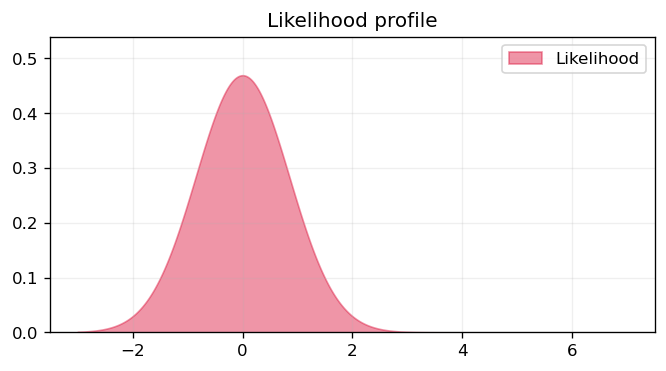

In [3]:
likelihood = gaussian_pdf(t, m=0.0, s=0.85)

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.fill_between(t, likelihood, color="crimson", alpha=0.45, label="Likelihood")
ax.set_title("Likelihood profile")
ax.set_ylim(0, likelihood.max() * 1.15)
ax.legend()
ax.grid(alpha=0.2)
plt.show()


## Posterior computation

Multiply and renormalize densities to obtain a valid posterior.


In [4]:
def posterior_from_prior(prior_mean, prior_std):
    prior = gaussian_pdf(t, m=prior_mean, s=prior_std)
    post = prior * likelihood
    post /= np.trapezoid(post, t)
    return prior, post


## Interactive prior influence

Observe how posterior mode interpolates prior mode and likelihood mode.


## Posterior moments

Compute posterior mean and variance numerically.


In [5]:
prior, post = posterior_from_prior(2.4, 0.65)
m_post = np.trapezoid(t * post, t)
v_post = np.trapezoid((t - m_post) ** 2 * post, t)
print("Posterior mean:", round(float(m_post), 4))
print("Posterior std :", round(float(np.sqrt(v_post)), 4))


Posterior mean: 1.5144
Posterior std : 0.5163


## Bibliographical resources

- Andrew Gelman et al., *Bayesian Data Analysis*.
- David MacKay, *Information Theory, Inference, and Learning Algorithms*.
- Kevin Murphy, *Probabilistic Machine Learning*.
